In [122]:
# Importing Libraries
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt  

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df=df[df['job_country']=='United States']

In [123]:
df['job_posted_month']=df['job_posted_date'].dt.month
df_pivot=df.pivot_table(
    columns='job_title_short',
    index='job_posted_month',
    aggfunc='size'
)
df_pivot


job_title_short,Business Analyst,Cloud Engineer,Data Analyst,Data Engineer,Data Scientist,Machine Learning Engineer,Senior Data Analyst,Senior Data Engineer,Senior Data Scientist,Software Engineer
job_posted_month,,,,,,,,,,
1,527,36,8494,2655,6915,60,1544,773,1552,114
2,447,24,6124,3060,4956,56,1258,878,1127,90
3,438,19,6218,3183,4779,59,1114,829,1150,115
4,565,40,6049,2801,4867,51,1025,781,991,112
5,279,20,4993,2976,4377,49,839,746,914,90
6,446,32,5683,2893,4645,48,1009,812,1033,93
7,581,39,5201,2570,4876,65,883,747,1095,153
8,903,39,6634,3269,6318,68,1186,903,1515,194
9,897,50,4639,3224,4568,113,805,775,1014,228


In [124]:
df_pivot=df_pivot.reset_index()

In [125]:
df_pivot['month']=pd.to_datetime(df_pivot['job_posted_month'],format='%m').dt.month_name()

In [126]:
df_pivot=df_pivot.sort_values('job_posted_month')

In [127]:
df_pivot=df_pivot.set_index('month')

In [128]:
df_pivot=df_pivot.drop(columns=['job_posted_month'])

In [129]:
df_pivot
title=['Data Engineer','Data Analyst','Data Scientist']

In [130]:
df_pivot=df_pivot[title]

In [131]:
df_pivot

job_title_short,Data Engineer,Data Analyst,Data Scientist
month,,,
January,2655,8494,6915
February,3060,6124,4956
March,3183,6218,4779
April,2801,6049,4867
May,2976,4993,4377
June,2893,5683,4645
July,2570,5201,4876
August,3269,6634,6318
September,3224,4639,4568


<Axes: xlabel='month'>

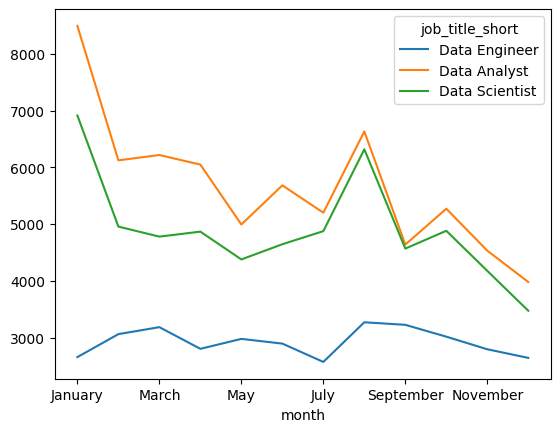

In [132]:
df_pivot.plot()